# 🇹🇷 FullSubNet+ Türkçe Fine-Tune — Düzeltilmiş Notebook

**Orijinal koddan yapılan kritik düzeltmeler:**

| # | Önem | Sorun → Çözüm |
|---|------|--------------|
| 1 | 🔴 KRİTİK | `enhance_batch` drop_band freq mismatch → inference'de drop_band uygulanıyor artık |
| 2 | 🔴 KRİTİK | `match_target_to_pred` yanlış permute → `[B,F,T,2]→[B,2,F,T]` düzeltildi |
| 3 | 🔴 KRİTİK | Pretrained checkpoint yükleme yoktu → Google Drive'dan `gdown` ile otomatik indirilir |
| 4 | 🔴 KRİTİK | `noise_paths` make_pairs_for_split içinde global scope referansı → parametre olarak geçildi |
| 5 | 🟡 ORTA | `torch.cuda.amp.GradScaler` deprecated → `torch.amp.GradScaler('cuda')` |
| 6 | 🟡 ORTA | `learning_rate=1e-3` fine-tune için yüksek → `5e-4`, pretrained varsa `1e-4` |
| 7 | 🟡 ORTA | AMP scope yanlış (stft dışarıda) → tüm forward_loss AMP içine alındı |
| 8 | 🟡 ORTA | `torchcodec` gereksiz paket (video decoder) → kaldırıldı |
| 9 | 🟢 KÜÇÜK | val `drop_last=False` + drop_band → `drop_last=True` yapıldı |

**Kullanım:** 16 kHz, FLEURS+CV17 Türkçe veri, Drive'daki DNS noise, pretrained FullSubNet+ checkpoint fine-tune.

In [1]:
# ============================================================
# Hücre 1 - GPU kontrolü, repo clone ve paket kurulumu
# ============================================================

!nvidia-smi

# torchcodec KALDIRILDI (video decoder, ses ile ilgisi yok)
!pip install -q \
    datasets \
    soundfile \
    librosa \
    scipy \
    tqdm \
    matplotlib \
    tensorboard \
    toml \
    colorful \
    mir_eval \
    torch_complex \
    pystoi \
    pesq \
    joblib \
    Cython \
    gdown

!rm -rf /content/FullSubNet-plus
!git clone --depth 1 https://github.com/RookieJunChen/FullSubNet-plus.git /content/FullSubNet-plus
print("✅ Kurulum tamamlandı")

Sun May 24 13:55:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ============================================================
# Hücre 2 - Drive mount, importlar ve temel ayarlar
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os, sys, gc, json, math, time, random, warnings, shutil
from pathlib import Path

import numpy as np
import soundfile as sf
import torch
import torchaudio
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from datasets import load_dataset
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# NumPy 2.x uyumluluk yamaları
if not hasattr(np, "complex"):
    np.complex = np.complex128
if not hasattr(np, "float"):
    np.float = float

REPO_DIR = Path("/content/FullSubNet-plus")
sys.path.insert(0, str(REPO_DIR))
sys.path.insert(0, str(REPO_DIR / "speech_enhance"))

from fullsubnet_plus.model.fullsubnet_plus import FullSubNet_Plus
from audio_zen.acoustics.feature import stft, istft, mag_phase, drop_band
from audio_zen.acoustics.mask import build_complex_ideal_ratio_mask, decompress_cIRM

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

Mounted at /content/drive
DEVICE: cuda
GPU: Tesla T4
VRAM GB: 15.64


In [3]:
# ============================================================
# Hücre 3 - Konfigürasyon
# ============================================================

CFG = {
    # Veri miktarı
    "n_fleurs": 2000,   # FLEURS tr_tr (repeat ile 7k'ya tamamlanır, gerçekte ~2k unique)
    "n_cv":     12000,   # CommonVoice 17 TR

    # FullSubNet+ resmi config → 16 kHz zorunlu
    "sample_rate":   16000,
    "min_duration_s": 1.0,
    "max_duration_s": 20.0,

    # DNS noise
    "use_dns_noise_from_drive": True,
    "dns_noise_source": "/content/drive/MyDrive/Denoiser/Datasets/DNS-Challenge/datasets/noise",
    "noise_files": 500,         # 300-500 hız, 1000-3000 kalite

    # Augmentation
    "snr_levels_db":      [-5, 0, 5, 10, 15, 20],
    "augments_per_clean": 3,
    "split_before_augment": True,
    "val_split": 0.10,

    # STFT (FullSubNet+ resmi değerler)
    "n_fft":      512,
    "win_length": 512,
    "hop_length": 256,

    # Eğitim
    "sub_sample_length_s": 3.072,
    "batch_size":   32,          # OOM → 4 yap
    "num_workers":  2,
    "epochs":       60,         # Fine-tune için artırıldı

    # DÜZELTME: fine-tune LR — orijinalde 1e-3 çok yüksekti
    "learning_rate": 1e-4,      # Pretrained checkpoint varsa 1e-4 daha güvenli
    "grad_clip":    1.0, # 10.0 dı
    "use_amp":      False,

    "val_max_batches":   300,
    "save_sample_count": 3,

    # FullSubNet+ model parametreleri (resmi config'den)
    "sb_num_neighbors": 15,
    "fb_num_neighbors":  0,
    "num_freqs":       257,
    "look_ahead":        2,
    "sequence_model": "LSTM",
    "fb_output_activate_function": "ReLU",
    "sb_output_activate_function": False,
    "channel_attention_model": "TSSE",
    "fb_model_hidden_size": 512,
    "sb_model_hidden_size": 384,
    "weight_init":  False,
    "norm_type":    "offline_laplace_norm",
    "num_groups_in_drop_band": 2,
    "kersize":      [3, 5, 10],
    "subband_num":  1,

    # Pretrained checkpoint (Google Drive linki — README'den)
    # https://drive.google.com/file/d/1UJSt1G0P_aXry-u79LLU_l9tCnNa2u7C/view
    "pretrained_checkpoint_gid": "1UJSt1G0P_aXry-u79LLU_l9tCnNa2u7C",
    "use_pretrained": True,     # False yaparsan sıfırdan eğitim
}

BASE_DIR   = Path("/content/drive/MyDrive/fullsubnet_plus_tr")

# Veri local diske — hızlı yaz/oku, runtime silinince gider (önemli değil)
LOCAL_DIR  = Path("/content/fsn_local")
CLEAN_DIR  = LOCAL_DIR / "clean_16k"
NOISE_DIR  = LOCAL_DIR / "dns_noise_subset_16k"
PAIR_DIR   = LOCAL_DIR / "pairs_16k"

# Önemli şeyler Drive'da — runtime silinse bile kaybolmaz
CKPT_DIR   = BASE_DIR / "checkpoints"
LOG_DIR    = BASE_DIR / "logs"
SAMPLE_DIR = BASE_DIR / "samples"

for d in [CLEAN_DIR, NOISE_DIR, PAIR_DIR, CKPT_DIR, LOG_DIR, SAMPLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

for d in [CLEAN_DIR, NOISE_DIR, PAIR_DIR, CKPT_DIR, LOG_DIR, SAMPLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(json.dumps(CFG, indent=2, default=str))
print("BASE_DIR:", BASE_DIR)

{
  "n_fleurs": 2000,
  "n_cv": 12000,
  "sample_rate": 16000,
  "min_duration_s": 1.0,
  "max_duration_s": 20.0,
  "use_dns_noise_from_drive": true,
  "dns_noise_source": "/content/drive/MyDrive/Denoiser/Datasets/DNS-Challenge/datasets/noise",
  "noise_files": 500,
  "snr_levels_db": [
    -5,
    0,
    5,
    10,
    15,
    20
  ],
  "augments_per_clean": 3,
  "split_before_augment": true,
  "val_split": 0.1,
  "n_fft": 512,
  "win_length": 512,
  "hop_length": 256,
  "sub_sample_length_s": 3.072,
  "batch_size": 32,
  "num_workers": 2,
  "epochs": 60,
  "learning_rate": 0.0001,
  "grad_clip": 1.0,
  "use_amp": false,
  "val_max_batches": 300,
  "save_sample_count": 3,
  "sb_num_neighbors": 15,
  "fb_num_neighbors": 0,
  "num_freqs": 257,
  "look_ahead": 2,
  "sequence_model": "LSTM",
  "fb_output_activate_function": "ReLU",
  "sb_output_activate_function": false,
  "channel_attention_model": "TSSE",
  "fb_model_hidden_size": 512,
  "sb_model_hidden_size": 384,
  "weight_init": fal

In [4]:
# Sadece fleurs dosyalarını sil
for f in CLEAN_DIR.glob("fleurs_*.wav"):
    f.unlink()
print("FLEURS dosyaları silindi, Hücre 7'yi tekrar çalıştır")

FLEURS dosyaları silindi, Hücre 7'yi tekrar çalıştır


In [5]:
# ============================================================
# Hücre 4 - Audio yardımcı fonksiyonları
# ============================================================

def to_mono_float32(audio: np.ndarray) -> np.ndarray:
    audio = np.asarray(audio, dtype=np.float32)
    if audio.ndim > 1:
        audio = audio.mean(axis=-1)
    return audio.astype(np.float32)

def peak_normalize(audio: np.ndarray, peak_target: float = 0.9):
    audio = to_mono_float32(audio)
    peak = np.max(np.abs(audio)) + 1e-8
    if peak < 1e-5:
        return None
    return (audio / peak * peak_target).astype(np.float32)

def resample_np(audio: np.ndarray, orig_sr: int, target_sr: int) -> np.ndarray:
    audio = to_mono_float32(audio)
    if orig_sr == target_sr:
        return audio.astype(np.float32)
    t = torch.from_numpy(audio).float().unsqueeze(0)
    y = torchaudio.functional.resample(t, orig_sr, target_sr)
    return y.squeeze(0).numpy().astype(np.float32)

def load_hf_audio(item, target_sr: int):
    try:
        arr = np.array(item["audio"]["array"], dtype=np.float32)
        sr  = int(item["audio"]["sampling_rate"])
        arr = to_mono_float32(arr)
        arr = resample_np(arr, sr, target_sr)
        dur = len(arr) / target_sr
        if not (CFG["min_duration_s"] <= dur <= CFG["max_duration_s"]):
            return None
        arr = peak_normalize(arr, 0.9)
        return arr
    except Exception:
        return None

def load_wav_any(path, target_sr: int) -> np.ndarray:
    audio, sr = sf.read(str(path), dtype="float32", always_2d=False)
    audio = to_mono_float32(audio)
    audio = resample_np(audio, sr, target_sr)
    return audio.astype(np.float32)

def write_wav(path: Path, audio: np.ndarray, sr: int):
    path.parent.mkdir(parents=True, exist_ok=True)
    sf.write(str(path), audio.astype(np.float32), sr)

print("✅ Yardımcı fonksiyonlar yüklendi")

✅ Yardımcı fonksiyonlar yüklendi


In [6]:
# ============================================================
# Hücre 5 - Pretrained checkpoint indirme (DÜZELTME: orijinal kodda yoktu)
# ============================================================
# FullSubNet+ pretrained ağırlıkları resmi Drive linki:
# https://drive.google.com/file/d/1UJSt1G0P_aXry-u79LLU_l9tCnNa2u7C/view

import gdown

PRETRAINED_PATH = CKPT_DIR / "pretrained_fullsubnet_plus.tar"

def download_pretrained():
    if PRETRAINED_PATH.exists():
        print(f"✅ Pretrained checkpoint mevcut: {PRETRAINED_PATH}")
        return
    gid = CFG["pretrained_checkpoint_gid"]
    print(f"📥 Pretrained checkpoint indiriliyor (gid={gid})...")
    gdown.download(id=gid, output=str(PRETRAINED_PATH), quiet=False)
    if PRETRAINED_PATH.exists():
        size_mb = PRETRAINED_PATH.stat().st_size / 1e6
        print(f"✅ İndirildi: {size_mb:.1f} MB")
    else:
        print("⚠️  İndirme başarısız — use_pretrained=False ile sıfırdan eğitim yapılacak")
        CFG["use_pretrained"] = False

if CFG["use_pretrained"]:
    download_pretrained()
else:
    print("ℹ️  use_pretrained=False — sıfırdan eğitim")

✅ Pretrained checkpoint mevcut: /content/drive/MyDrive/fullsubnet_plus_tr/checkpoints/pretrained_fullsubnet_plus.tar


In [7]:
# ============================================================
# Hücre 6 - DNS Challenge noise subset hazırlama
# ============================================================

def generate_synthetic_noise(target_dir: Path, n: int, sr: int):
    target_dir.mkdir(parents=True, exist_ok=True)
    start_idx = len(sorted(target_dir.glob("*.wav")))
    for k in tqdm(range(n), desc="Sentetik gürültü"):
        i = start_idx + k
        duration = random.uniform(3.0, 8.0)
        samples  = int(duration * sr)
        choice   = i % 4
        if choice == 0:
            noise = np.random.randn(samples).astype(np.float32)
        elif choice == 1:
            white = np.random.randn(samples)
            freqs = np.fft.rfftfreq(samples); freqs[0] = 1.0
            noise = np.fft.irfft(np.fft.rfft(white) / np.sqrt(freqs), n=samples).astype(np.float32)
        elif choice == 2:
            noise = np.cumsum(np.random.randn(samples)).astype(np.float32)
        else:
            from scipy import signal
            noise = np.random.randn(samples).astype(np.float32)
            b, a = signal.butter(4, [200/(sr/2), 3400/(sr/2)], "bandpass")
            noise = signal.lfilter(b, a, noise).astype(np.float32)
        n_arr = peak_normalize(noise, 0.8)
        if n_arr is not None:
            write_wav(target_dir / f"synth_{i:05d}.wav", n_arr, sr)

def list_audio_files_recursive(source_dir: Path):
    files = []
    for ext in ["*.wav", "*.flac", "*.mp3", "*.ogg"]:
        files.extend(source_dir.rglob(ext))
    return sorted(files)

def prepare_dns_noise_from_drive(source_dir: Path, target_dir: Path, max_files: int, sr: int):
    target_dir.mkdir(parents=True, exist_ok=True)
    existing = sorted(target_dir.glob("dns_noise_*.wav"))
    if len(existing) >= max_files:
        print(f"✅ DNS noise subset zaten hazır: {len(existing)} dosya")
        return existing[:max_files]
    if not source_dir.exists():
        raise FileNotFoundError(f"DNS noise source bulunamadı: {source_dir}")
    source_files = list_audio_files_recursive(source_dir)
    if not source_files:
        raise RuntimeError(f"DNS noise dosyası bulunamadı: {source_dir}")
    print(f"DNS source toplam dosya: {len(source_files)}")
    random.Random(SEED).shuffle(source_files)
    need = max_files - len(existing); saved = len(existing); used = 0
    for src in tqdm(source_files, desc="DNS noise subset hazırlanıyor"):
        if used >= need: break
        out_path = target_dir / f"dns_noise_{saved:05d}.wav"
        if out_path.exists(): saved += 1; continue
        try:
            audio = load_wav_any(src, sr)
            if len(audio) < sr: continue
            audio = peak_normalize(audio, 0.8)
            if audio is None: continue
            write_wav(out_path, audio, sr); saved += 1; used += 1
        except Exception: continue
    noise_files = sorted(target_dir.glob("dns_noise_*.wav"))
    print(f"✅ DNS noise subset: {len(noise_files)} dosya")
    if not noise_files:
        raise RuntimeError("DNS source bulundu ama hiç noise hazırlanamadı.")
    return noise_files[:max_files]

def prepare_audioset_or_synthetic(target_dir: Path, max_files: int, sr: int):
    target_dir.mkdir(parents=True, exist_ok=True)
    existing = sorted(list(target_dir.glob("*.wav")) + list(target_dir.glob("*.flac")))
    if len(existing) >= max_files:
        print(f"✅ Gürültü hazır: {len(existing)} dosya"); return existing[:max_files]
    print("AudioSet noise deneniyor. Başarısız olursa sentetik gürültü üretilecek.")
    saved = len(existing)
    try:
        ds_noise = load_dataset("agkphysics/AudioSet", "balanced", split="train", streaming=True)
        for item in tqdm(ds_noise, total=max_files, desc="AudioSet noise"):
            if saved >= max_files: break
            try:
                audio = load_hf_audio(item, sr)
                if audio is None: continue
                write_wav(target_dir / f"noise_{saved:05d}.wav", audio, sr); saved += 1
            except Exception: continue
    except Exception as e:
        print("⚠️ AudioSet indirilemedi:", repr(e))
    existing = sorted(list(target_dir.glob("*.wav")) + list(target_dir.glob("*.flac")))
    if len(existing) < max_files:
        generate_synthetic_noise(target_dir, max_files - len(existing), sr)
    existing = sorted(list(target_dir.glob("*.wav")) + list(target_dir.glob("*.flac")))
    print(f"✅ Gürültü dosyası: {len(existing)}")
    return existing[:max_files]

def prepare_noise(target_dir, max_files, sr):
    if CFG.get("use_dns_noise_from_drive", False):
        try:
            print("📁 Drive DNS noise:", CFG["dns_noise_source"])
            return prepare_dns_noise_from_drive(Path(CFG["dns_noise_source"]), target_dir, max_files, sr)
        except Exception as e:
            print("⚠️ DNS Drive noise kullanılamadı:", repr(e))
            print("Fallback: AudioSet/sentetik noise")
    return prepare_audioset_or_synthetic(target_dir, max_files, sr)

noise_paths = prepare_noise(NOISE_DIR, CFG["noise_files"], CFG["sample_rate"])
print("Kullanılacak noise dosyası:", len(noise_paths))
print("İlk 3:", noise_paths[:3])

📁 Drive DNS noise: /content/drive/MyDrive/Denoiser/Datasets/DNS-Challenge/datasets/noise
DNS source toplam dosya: 659


DNS noise subset hazırlanıyor:   0%|          | 0/659 [00:00<?, ?it/s]

✅ DNS noise subset: 500 dosya
Kullanılacak noise dosyası: 500
İlk 3: [PosixPath('/content/fsn_local/dns_noise_subset_16k/dns_noise_00000.wav'), PosixPath('/content/fsn_local/dns_noise_subset_16k/dns_noise_00001.wav'), PosixPath('/content/fsn_local/dns_noise_subset_16k/dns_noise_00002.wav')]


In [8]:
# ============================================================
# Hücre 7 - Temiz Türkçe veri: FLEURS + CommonVoice 17 TR
# Önce Drive yedeğine bakar, yoksa HuggingFace'ten indirir
# ============================================================

def save_clean_batch(source_name, items, n_max, target_dir):
    saved_paths, failed = [], 0
    pbar = tqdm(items, total=n_max, desc=f"{source_name} kaydediliyor")
    for item in pbar:
        if len(saved_paths) >= n_max: break
        audio = load_hf_audio(item, CFG["sample_rate"])
        if audio is None: failed += 1; continue
        path = target_dir / f"{source_name}_{len(saved_paths):06d}.wav"
        write_wav(path, audio, CFG["sample_rate"])
        saved_paths.append(path)
        pbar.set_postfix({"saved": len(saved_paths), "failed": failed})
    print(f"✅ {source_name}: {len(saved_paths)} kayıt, {failed} atlandı")
    return saved_paths


def copy_from_drive_backup(pattern, target_dir, n_max, label):
    """Drive yedeğinden local'e kopyalar. Yeterli dosya varsa True döner."""
    drive_backup = BASE_DIR / "clean_16k"
    if not drive_backup.exists():
        return False
    backup_files = sorted(drive_backup.glob(pattern))
    if len(backup_files) < n_max:
        print(f"  Drive yedeğinde {len(backup_files)} {label} var, {n_max} gerekli — HF'ten indirilecek")
        return False
    print(f"✅ {label} Drive yedeğinden yükleniyor ({len(backup_files)} dosya)...")
    copied = []
    for f in tqdm(backup_files[:n_max], desc=f"Drive → Local ({label})"):
        dest = target_dir / f.name
        if not dest.exists():
            shutil.copy2(f, dest)
        copied.append(dest)
    print(f"✅ {len(copied)} {label} dosyası local'e kopyalandı")
    return True


def prepare_fleurs():
    # 1. Local'de yeterli dosya var mı?
    existing = sorted(CLEAN_DIR.glob("fleurs_*.wav"))
    if len(existing) >= CFG["n_fleurs"]:
        print(f"✅ FLEURS local'de hazır: {len(existing)} dosya")
        return existing[:CFG["n_fleurs"]]

    # 2. Drive yedeğinden kopyala
    if copy_from_drive_backup("fleurs_*.wav", CLEAN_DIR, CFG["n_fleurs"], "FLEURS"):
        return sorted(CLEAN_DIR.glob("fleurs_*.wav"))[:CFG["n_fleurs"]]

    # 3. HuggingFace'ten indir
    print("📥 FLEURS tr_tr indiriliyor...")
    from datasets import concatenate_datasets
    splits = []
    for split in ["train", "validation", "test"]:
        ds = load_dataset("google/fleurs", "tr_tr", split=split)
        print(f"  FLEURS {split}: {len(ds)}"); splits.append(ds)
    all_ds = concatenate_datasets(splits)
    print("FLEURS toplam:", len(all_ds))
    if len(all_ds) < CFG["n_fleurs"]:
        factor = (CFG["n_fleurs"] // len(all_ds)) + 1
        all_ds = concatenate_datasets([all_ds] * factor)
        print(f"  {factor}x tekrarlandı: {len(all_ds)}")
    all_ds = all_ds.shuffle(seed=SEED).select(range(min(CFG["n_fleurs"], len(all_ds))))
    paths = save_clean_batch("fleurs", all_ds, CFG["n_fleurs"], CLEAN_DIR)
    del all_ds; gc.collect()
    return paths


def prepare_cv():
    # 1. Local'de yeterli dosya var mı?
    existing = sorted(CLEAN_DIR.glob("cv17_*.wav"))
    if len(existing) >= CFG["n_cv"]:
        print(f"✅ CV17 local'de hazır: {len(existing)} dosya")
        return existing[:CFG["n_cv"]]

    # 2. Drive yedeğini atla — HuggingFace çok daha hızlı
    print("📥 CommonVoice 17 TR indiriliyor (HuggingFace)...")
    cv_ds = load_dataset("ysdede/commonvoice_17_tr_fixed", split="train")
    print("CV17 train:", len(cv_ds))
    cv_ds = cv_ds.shuffle(seed=SEED)
    paths = save_clean_batch("cv17", cv_ds, CFG["n_cv"], CLEAN_DIR)
    del cv_ds; gc.collect()
    return paths

fleurs_paths    = prepare_fleurs()
cv_paths        = prepare_cv()
all_clean_paths = fleurs_paths + cv_paths
random.Random(SEED).shuffle(all_clean_paths)
print(f"\nToplam temiz ses: {len(all_clean_paths)} dosya")

  Drive yedeğinde 1927 FLEURS var, 2000 gerekli — HF'ten indirilecek
📥 FLEURS tr_tr indiriliyor...


README.md: 0.00B [00:00, ?B/s]

parquet-data/tr_tr/train-00000-of-00001.(…):   0%|          | 0.00/1.90G [00:00<?, ?B/s]

parquet-data/tr_tr/validation-00000-of-0(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

parquet-data/tr_tr/test-00000-of-00001.p(…):   0%|          | 0.00/590M [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/8639 [00:00<?, ? examples/s]

Generating validated split:   0%|          | 0/46345 [00:00<?, ? examples/s]

CV17 train: 26501


cv17 kaydediliyor:   0%|          | 0/12000 [00:00<?, ?it/s]

✅ cv17: 12000 kayıt, 10 atlandı

Toplam temiz ses: 13927 dosya


In [9]:
# ============================================================
# Hücre 8 — ÖNCEKİ SÜRÜMDE pair'leri diske yazıyordu (~1 saat)
#            YENİ SÜRÜMDE: Bu adım kaldırıldı.
#            Hücre 9'daki OnTheFlyDataset her __getitem__'de
#            anında noise karıştırdığı için disk yazımı gerekmiyor.
#            Hücre 6 ve 7 çalıştıktan sonra direkt Hücre 9'a geç.
# ============================================================
print('ℹ️  Hücre 8 artık boş — pair üretimi on-the-fly (Hücre 9).')

ℹ️  Hücre 8 artık boş — pair üretimi on-the-fly (Hücre 9).


In [10]:
# ============================================================
# Hücre 9 - On-the-fly Dataset ve DataLoader
# Pair'ler artık DISK'E YAZILMIYOR — RAM'de anında karıştırılıyor.
# Hücre 8 (pair üretimi) tamamen KALDIRILDI — artık gerek yok.
#
# Avantajlar:
#   - Augmentation adımı ~1 saat → birkaç saniye
#   - Drive'a 42k dosya yazmak yok
#   - Her epoch farklı SNR/noise karışımı → daha iyi genelleme
#   - augments_per_clean CFG'den kaldırıldı (epoch sayısı yerine geçiyor)
# ============================================================

class OnTheFlyDataset(Dataset):
    """
    Clean sesleri bellekte (veya ihtiyaç anında diskten) yükler,
    her __getitem__ çağrısında rastgele bir noise dosyası ile karıştırır.
    Disk'e hiç noisy dosyası yazılmaz.
    """
    def __init__(self, clean_paths, noise_paths, sr, chunk_samples,
                 snr_levels, random_crop=True, noise_cache_size=80):
        self.clean_paths   = [str(p) for p in clean_paths]
        self.noise_paths   = [str(p) for p in noise_paths]
        self.sr            = sr
        self.chunk         = chunk_samples
        self.snr_levels    = snr_levels
        self.random_crop   = random_crop
        # Sık kullanılan noise'ları RAM'de tut (Drive okumayı azaltır)
        self._noise_cache  = {}
        self._cache_size   = noise_cache_size

    def __len__(self):
        return len(self.clean_paths)

    def _get_noise(self, path):
        if path not in self._noise_cache:
            arr = load_wav_any(path, self.sr)
            if len(self._noise_cache) >= self._cache_size:
                self._noise_cache.pop(next(iter(self._noise_cache)))
            self._noise_cache[path] = arr
        return self._noise_cache[path]

    def _mix(self, clean, noise, snr_db):
        n = len(clean)
        if len(noise) >= n:
            start = random.randint(0, len(noise) - n)
            noise = noise[start:start+n]
        else:
            noise = np.tile(noise, (n // len(noise)) + 1)[:n]
        p_c = np.mean(clean**2) + 1e-10
        p_n = np.mean(noise**2) + 1e-10
        scale = np.sqrt(p_c / (10**(snr_db/10) * p_n))
        noisy = clean + scale * noise
        peak = np.abs(noisy).max() + 1e-8
        if peak > 0.99:
            noisy = noisy / peak * 0.9; clean = clean / peak * 0.9
        return noisy.astype(np.float32), clean.astype(np.float32)

    def _crop_or_pad(self, arr):
        if len(arr) >= self.chunk:
            start = random.randint(0, len(arr)-self.chunk) if self.random_crop \
                    else max(0, (len(arr)-self.chunk)//2)
            return arr[start:start+self.chunk]
        return np.pad(arr, (0, self.chunk - len(arr)))

    def __getitem__(self, idx):
        # 1. Clean ses yükle
        clean = load_wav_any(self.clean_paths[idx], self.sr)
        clean = self._crop_or_pad(clean)
        # 2. Rastgele noise + SNR seç
        noise_path = random.choice(self.noise_paths)
        snr_db     = random.choice(self.snr_levels)
        noise      = self._get_noise(noise_path)
        # 3. Karıştır
        noisy, clean = self._mix(clean, noise, snr_db)
        return torch.from_numpy(noisy), torch.from_numpy(clean)


# Train/val split — clean dosya listesi üzerinden
val_size    = int(len(all_clean_paths) * CFG["val_split"])
val_clean   = all_clean_paths[:val_size]
train_clean = all_clean_paths[val_size:]

chunk_samples = int(CFG["sample_rate"] * CFG["sub_sample_length_s"])

train_ds = OnTheFlyDataset(
    train_clean, noise_paths,
    sr=CFG["sample_rate"], chunk_samples=chunk_samples,
    snr_levels=CFG["snr_levels_db"], random_crop=True
)
val_ds = OnTheFlyDataset(
    val_clean, noise_paths,
    sr=CFG["sample_rate"], chunk_samples=chunk_samples,
    snr_levels=CFG["snr_levels_db"], random_crop=False
)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True, drop_last=True)

print(f"Train: {len(train_ds)} clean dosya | Val: {len(val_ds)} clean dosya")
print(f"Train batches/epoch: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Her epoch farklı noise/SNR kombinasyonu — augments_per_clean artık gerekmiyor")

Train: 12535 clean dosya | Val: 1392 clean dosya
Train batches/epoch: 391 | Val batches: 43
Her epoch farklı noise/SNR kombinasyonu — augments_per_clean artık gerekmiyor


In [11]:
# ============================================================
# Hücre 10 - FullSubNet+ modeli, pretrained yükleme, optimizer
# DÜZELTME: pretrained checkpoint yükleme eklendi (orijinalde yoktu)
# ============================================================

model = FullSubNet_Plus(
    sb_num_neighbors=CFG["sb_num_neighbors"],
    fb_num_neighbors=CFG["fb_num_neighbors"],
    num_freqs=CFG["num_freqs"],
    look_ahead=CFG["look_ahead"],
    sequence_model=CFG["sequence_model"],
    fb_output_activate_function=CFG["fb_output_activate_function"],
    sb_output_activate_function=CFG["sb_output_activate_function"],
    channel_attention_model=CFG["channel_attention_model"],
    fb_model_hidden_size=CFG["fb_model_hidden_size"],
    sb_model_hidden_size=CFG["sb_model_hidden_size"],
    weight_init=CFG["weight_init"],
    norm_type=CFG["norm_type"],
    num_groups_in_drop_band=CFG["num_groups_in_drop_band"],
    kersize=CFG["kersize"],
    subband_num=CFG["subband_num"],
).to(DEVICE)

# Pretrained ağırlıkları yükle
if CFG["use_pretrained"] and PRETRAINED_PATH.exists():
    print("📦 Pretrained checkpoint yükleniyor...")
    ckpt = torch.load(str(PRETRAINED_PATH), map_location="cpu", weights_only=False)
    # Resmi checkpoint formatı: {"model": state_dict} veya doğrudan state_dict
    state_dict = ckpt.get("model", ckpt)
    # DataParallel prefix'ini temizle
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print(f"✅ Pretrained yüklendi — missing: {len(missing)}, unexpected: {len(unexpected)}")
    if missing:
        print("  Missing keys:", missing[:5])
else:
    print("ℹ️  Pretrained yok veya devre dışı — sıfırdan başlıyor")

# Optimizer — DÜZELTME: fine-tune LR düşürüldü (orijinalde 1e-3 → şimdi 5e-4)
optimizer = torch.optim.Adam(model.parameters(), lr=CFG["learning_rate"], betas=(0.9, 0.999))

# DÜZELTME: deprecated torch.cuda.amp.GradScaler → torch.amp.GradScaler
scaler = torch.amp.GradScaler("cuda", enabled=CFG["use_amp"] and DEVICE.type == "cuda")

loss_fn = nn.MSELoss()

n_params = sum(p.numel() for p in model.parameters())
print(f"FullSubNet+ parametre sayısı: {n_params:,}")

📦 Pretrained checkpoint yükleniyor...
✅ Pretrained yüklendi — missing: 0, unexpected: 0
FullSubNet+ parametre sayısı: 8,675,102


In [12]:
# ============================================================
# Hücre 11 - Forward, enhance ve metrik fonksiyonları
# DÜZELTME 1: match_target_to_pred permute sırası düzeltildi [B,F,T,2]→[B,2,F,T]
# DÜZELTME 2: enhance_batch drop_band uyguluyor artık (freq shape mismatch çözüldü)
# DÜZELTME 3: AMP autocast tüm forward_loss'u kapsıyor (orijinalde stft dışarıdaydı)
# ============================================================

def torch_stft(y):
    return stft(y, n_fft=CFG["n_fft"], hop_length=CFG["hop_length"], win_length=CFG["win_length"])

def torch_istft(features, length=None):
    return istft(features, n_fft=CFG["n_fft"], hop_length=CFG["hop_length"],
                 win_length=CFG["win_length"], length=length)

def apply_drop_band_to_cirm(cirm: torch.Tensor, num_groups: int) -> torch.Tensor:
    """
    DÜZELTME: orijinal kodda permute sırası yanlıştı.
    cirm giriş: [B, F, T, 2]
    drop_band beklentisi: [B, num_channels, F, T] — burada num_channels=2 (real/imag)
    """
    # [B, F, T, 2] → [B, 2, F, T]
    x = cirm.permute(0, 3, 1, 2)   # [B, 2, F, T]
    x = drop_band(x, num_groups)   # [B, 2, F//g*g, T] (frekans azalır)
    # [B, 2, F', T] → [B, F', T, 2]
    return x.permute(0, 2, 3, 1)

def forward_loss(noisy, clean):
    was_training = model.training
    model.train()

    results = []
    for i in range(noisy.shape[0]):
        noisy_s = noisy[i:i+1]
        noisy_c = torch_stft(noisy_s)
        noisy_mag, _ = mag_phase(noisy_c)

        pred = model(noisy_mag.unsqueeze(1),
                     noisy_c.real.unsqueeze(1),
                     noisy_c.imag.unsqueeze(1))       # [1, 2, 257, T]

        mask_real = pred[:, 0, :, :]
        mask_imag = pred[:, 1, :, :]

        enhanced_real = mask_real * noisy_c.real - mask_imag * noisy_c.imag
        enhanced_imag = mask_real * noisy_c.imag + mask_imag * noisy_c.real

        enhanced_complex = torch.stack((enhanced_real, enhanced_imag), dim=-1)  # [1, F, T, 2]
        results.append(enhanced_complex.squeeze(0))

    if not was_training:
        model.eval()

    enhanced_batch = torch.stack(results)             # [B, F, T, 2]

    # Target: clean spektrogram
    clean_complex_list = []
    for i in range(clean.shape[0]):
        cc = torch_stft(clean[i:i+1])
        clean_complex_list.append(torch.stack((cc.real, cc.imag), dim=-1).squeeze(0))
    clean_batch = torch.stack(clean_complex_list)     # [B, F, T, 2]

    return loss_fn(enhanced_batch, clean_batch)


@torch.no_grad()
def enhance_batch(noisy: torch.Tensor) -> torch.Tensor:
    """
    Doğru enhance pipeline:
    - batch_size=1 ile çalışır (drop_band devreye girmez, F=257 tam çıkar)
    - Model çıktısı cIRM maskesi olarak noisy spektrograma uygulanır
    """
    results = []
    for i in range(noisy.shape[0]):
        noisy_s = noisy[i:i+1]                          # [1, T]
        noisy_c = torch_stft(noisy_s)                   # [1, 257, T]
        noisy_mag, _ = mag_phase(noisy_c)

        pred = model(noisy_mag.unsqueeze(1),             # [1, 2, 257, T]
                     noisy_c.real.unsqueeze(1),
                     noisy_c.imag.unsqueeze(1))

        mask_real = pred[:, 0, :, :]                    # [1, 257, T]
        mask_imag = pred[:, 1, :, :]

        enhanced_real = mask_real * noisy_c.real - mask_imag * noisy_c.imag
        enhanced_imag = mask_real * noisy_c.imag + mask_imag * noisy_c.real

        enhanced_complex = torch.stack((enhanced_real, enhanced_imag), dim=-1)
        enhanced = torch_istft(enhanced_complex, length=noisy_s.shape[-1])
        results.append(enhanced.squeeze(0))

    return torch.stack(results)


def si_sdr_torch(est, ref, eps=1e-8):
    est = est - est.mean(dim=-1, keepdim=True)
    ref = ref - ref.mean(dim=-1, keepdim=True)
    scale = (est * ref).sum(dim=-1, keepdim=True) / (ref.pow(2).sum(dim=-1, keepdim=True) + eps)
    proj  = scale * ref
    noise = est - proj
    return 10 * torch.log10((proj.pow(2).sum(dim=-1) + eps) / (noise.pow(2).sum(dim=-1) + eps))

print("✅ Forward / enhance / metrik fonksiyonları yüklendi")

✅ Forward / enhance / metrik fonksiyonları yüklendi


In [ ]:
# ============================================================
# Hücre 12 - Eğitim döngüsü
# ============================================================

EARLY_STOP_PATIENCE = 6
early_stop_counter  = 0

history = {"train_loss": [], "val_loss": [], "val_noisy_sisdr": [], "val_enhanced_sisdr": []}
best_val = float("inf")

print("🚀 FullSubNet+ Türkçe fine-tune başlıyor")
print(f"Epoch: {CFG['epochs']} | Batch: {CFG['batch_size']} | Device: {DEVICE} | LR: {CFG['learning_rate']}")
print("─" * 70)

for epoch in range(1, CFG["epochs"] + 1):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    train_total, train_steps = 0.0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:03d}/{CFG['epochs']} [Train]")
    for noisy, clean in pbar:
        noisy = noisy.to(DEVICE, non_blocking=True).float()
        clean = clean.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        loss = forward_loss(noisy, clean)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
        scaler.step(optimizer); scaler.update()
        train_total += loss.item(); train_steps += 1
        pbar.set_postfix({"loss": f"{loss.item():.5f}"})

    avg_train = train_total / max(train_steps, 1)

    # ── Validation ─────────────────────────────────────────────────────────
    model.eval()
    val_total, val_steps = 0.0, 0
    noisy_sisdr_list, enh_sisdr_list = [], []

    with torch.no_grad():
        for bidx, (noisy, clean) in enumerate(tqdm(val_loader, desc=f"Epoch {epoch:03d} [Val]")):
            if CFG["val_max_batches"] is not None and bidx >= CFG["val_max_batches"]:
                break
            noisy = noisy.to(DEVICE, non_blocking=True).float()
            clean = clean.to(DEVICE, non_blocking=True).float()
            loss = forward_loss(noisy, clean)
            val_total += loss.item(); val_steps += 1
            if bidx < 20:
                try:
                    enhanced = enhance_batch(noisy)
                    noisy_sisdr_list.append(si_sdr_torch(noisy, clean).mean().item())
                    enh_sisdr_list.append(si_sdr_torch(enhanced, clean).mean().item())
                except Exception:
                    pass

    avg_val      = val_total / max(val_steps, 1)
    avg_noisy_si = float(np.mean(noisy_sisdr_list)) if noisy_sisdr_list else None
    avg_enh_si   = float(np.mean(enh_sisdr_list))   if enh_sisdr_list   else None

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["val_noisy_sisdr"].append(avg_noisy_si)
    history["val_enhanced_sisdr"].append(avg_enh_si)

    is_best = avg_val < best_val
    ckpt_data = {"epoch": epoch, "model_state": model.state_dict(),
                 "optimizer_state": optimizer.state_dict(), "val_loss": avg_val, "config": CFG}
    if is_best:
        best_val = avg_val
        torch.save(ckpt_data, CKPT_DIR / "best_model.pt")
    torch.save(ckpt_data, CKPT_DIR / "latest_model.pt")

    with open(LOG_DIR / "history.json", "w") as f:
        json.dump(history, f, indent=2)

    flag = " ⭐ BEST" if is_best else ""
    si_str = f"{avg_noisy_si:.2f} → {avg_enh_si:.2f}" if avg_enh_si is not None else "N/A"
    print(f"Epoch {epoch:03d} | Train: {avg_train:.6f} | Val: {avg_val:.6f} | SI-SDR: {si_str}{flag}")

    # ── Early Stopping ─────────────────────────────────────────────────────
    if is_best:
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        print(f"           Early stop: {early_stop_counter}/{EARLY_STOP_PATIENCE}")
        if early_stop_counter >= EARLY_STOP_PATIENCE:
            print(f"\n⏹ Early stopping tetiklendi — {EARLY_STOP_PATIENCE} epoch boyunca iyileşme olmadı.")
            break

print("\n✅ Eğitim tamamlandı — Best val loss:", best_val)
print("Best checkpoint:", CKPT_DIR / "best_model.pt")

🚀 FullSubNet+ Türkçe fine-tune başlıyor
Epoch: 60 | Batch: 32 | Device: cuda | LR: 0.0001
──────────────────────────────────────────────────────────────────────


Epoch 001/60 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 001 [Val]:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 001 | Train: 0.102031 | Val: 0.051918 | SI-SDR: 7.67 → 14.43 ⭐ BEST


Epoch 002/60 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 017 | Train: 0.037887 | Val: 0.037388 | SI-SDR: 8.16 → 17.26
           Early stop: 5/6


Epoch 018/60 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b5838cc0ea0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b5838cc0ea0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 018 [Val]:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 018 | Train: 0.037271 | Val: 0.038308 | SI-SDR: 7.29 → 17.08
           Early stop: 6/6

⏹ Early stopping tetiklendi — 6 epoch boyunca iyileşme olmadı.

✅ Eğitim tamamlandı — Best val loss: 0.035723457091249695
Best checkpoint: /content/drive/MyDrive/fullsubnet_plus_tr/checkpoints/best_model.pt


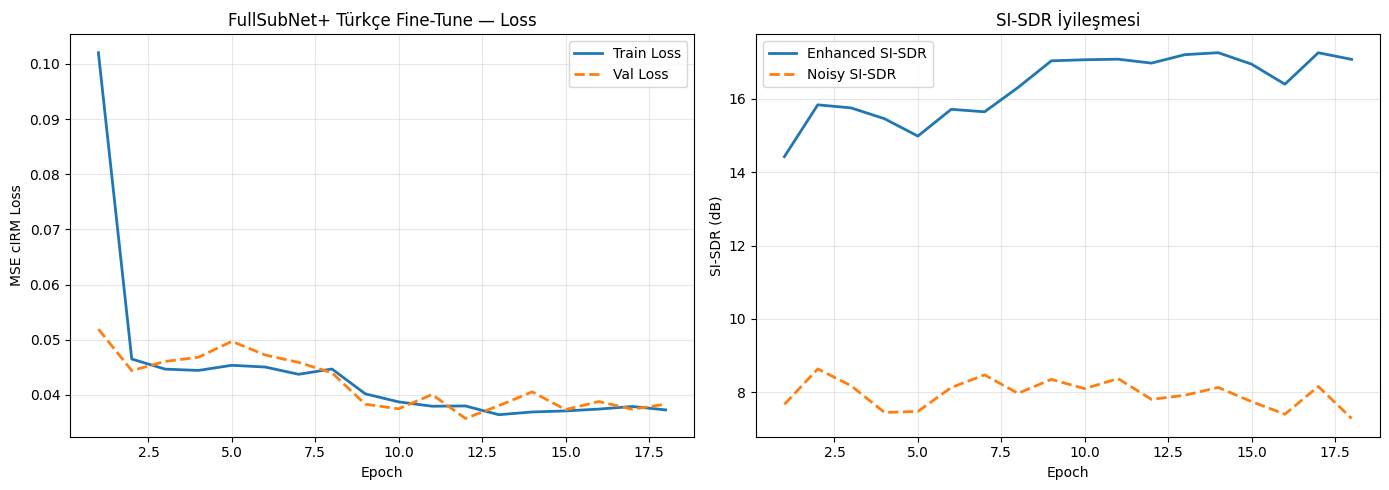

Kaydedildi: /content/drive/MyDrive/fullsubnet_plus_tr/logs/training_curves.png


In [ ]:
# ============================================================
# Hücre 13 - Loss ve SI-SDR grafiği
# ============================================================

with open(LOG_DIR / "history.json") as f:
    history = json.load(f)

epochs = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
ax1.plot(epochs, history["val_loss"],   label="Val Loss",   linewidth=2, linestyle="--")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE cIRM Loss")
ax1.set_title("FullSubNet+ Türkçe Fine-Tune — Loss"); ax1.legend(); ax1.grid(True, alpha=0.3)

enh_si = [x for x in history["val_enhanced_sisdr"] if x is not None]
noi_si = [x for x in history["val_noisy_sisdr"]    if x is not None]
if enh_si:
    ax2.plot(range(1, len(enh_si)+1), enh_si, label="Enhanced SI-SDR", linewidth=2)
    ax2.plot(range(1, len(noi_si)+1), noi_si, label="Noisy SI-SDR",    linewidth=2, linestyle="--")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("SI-SDR (dB)")
    ax2.set_title("SI-SDR İyileşmesi"); ax2.legend(); ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, "SI-SDR verisi yok", ha="center", va="center", transform=ax2.transAxes)

plt.tight_layout()
out = LOG_DIR / "training_curves.png"
plt.savefig(out, dpi=150); plt.show()
print("Kaydedildi:", out)

In [ ]:
# ============================================================
# Hücre 14 - Örnek sesleri üret ve dinle
# ============================================================

from IPython.display import Audio, display

ckpt = torch.load(CKPT_DIR / "best_model.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"✅ Best model yüklendi: epoch={ckpt['epoch']}, val_loss={ckpt['val_loss']:.6f}")

sample_loader = DataLoader(val_ds, batch_size=1, shuffle=True, drop_last=False)

for idx, (noisy, clean) in enumerate(sample_loader):
    if idx >= CFG["save_sample_count"]: break
    noisy = noisy.to(DEVICE).float(); clean = clean.to(DEVICE).float()
    with torch.no_grad():
        enhanced = enhance_batch(noisy)

    noisy_np    = noisy.squeeze(0).cpu().numpy()
    clean_np    = clean.squeeze(0).cpu().numpy()
    enhanced_np = enhanced.squeeze(0).cpu().numpy()

    write_wav(SAMPLE_DIR / f"sample_{idx}_noisy.wav",    noisy_np,    CFG["sample_rate"])
    write_wav(SAMPLE_DIR / f"sample_{idx}_clean.wav",    clean_np,    CFG["sample_rate"])
    write_wav(SAMPLE_DIR / f"sample_{idx}_enhanced.wav", enhanced_np, CFG["sample_rate"])

    print(f"\n===== SAMPLE {idx} =====")
    print("Gürültülü giriş:")
    display(Audio(noisy_np,    rate=CFG["sample_rate"]))
    print("Model çıktısı (temizlenmiş):")
    display(Audio(enhanced_np, rate=CFG["sample_rate"]))
    print("Orijinal (temiz):")
    display(Audio(clean_np,    rate=CFG["sample_rate"]))

✅ Best model yüklendi: epoch=12, val_loss=0.035723

===== SAMPLE 0 =====
Gürültülü giriş:


Model çıktısı (temizlenmiş):


Orijinal (temiz):



===== SAMPLE 1 =====
Gürültülü giriş:


Model çıktısı (temizlenmiş):


Orijinal (temiz):



===== SAMPLE 2 =====
Gürültülü giriş:


Model çıktısı (temizlenmiş):


Orijinal (temiz):


In [ ]:
# ============================================================
# Hücre 15 - Tek dosya inference fonksiyonu
# ============================================================

def enhance_file(input_path, output_path, checkpoint_path=None):
    if checkpoint_path is None:
        checkpoint_path = CKPT_DIR / "best_model.pt"
    ckpt = torch.load(str(checkpoint_path), map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"]); model.eval()
    audio   = load_wav_any(input_path, CFG["sample_rate"])
    audio_t = torch.from_numpy(audio).unsqueeze(0).to(DEVICE).float()
    with torch.no_grad():
        enhanced = enhance_batch(audio_t)
    enhanced_np = enhanced.squeeze(0).cpu().numpy()
    write_wav(Path(output_path), enhanced_np, CFG["sample_rate"])
    print(f"✅ Kaydedildi: {output_path}")
    return output_path

# Kullanım:
# enhance_file("/content/test_noisy.wav", "/content/test_enhanced.wav")

In [ ]:
# ============================================================
# Hücre 16 - Drive'a akıllı yedek alma
# ============================================================
import shutil
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
backup_dir = Path(f"/content/backup_{timestamp}")
backup_dir.mkdir(exist_ok=True)

# 1. Checkpointler
ckpt_backup = backup_dir / "checkpoints"
ckpt_backup.mkdir(exist_ok=True)
for f in CKPT_DIR.glob("*.pt"):
    shutil.copy2(f, ckpt_backup / f.name)
    print(f"✅ {f.name} ({f.stat().st_size/1e6:.1f} MB)")

# 2. Log ve history
log_backup = backup_dir / "logs"
log_backup.mkdir(exist_ok=True)
for f in LOG_DIR.glob("*"):
    shutil.copy2(f, log_backup / f.name)
    print(f"✅ {f.name}")

# 3. Sample sesler
sample_backup = backup_dir / "samples"
sample_backup.mkdir(exist_ok=True)
for f in SAMPLE_DIR.glob("*.wav"):
    shutil.copy2(f, sample_backup / f.name)
    print(f"✅ {f.name}")

# 4. Zip yap ve Drive'a taşı
zip_name = f"/content/drive/MyDrive/fullsubnet_plus_tr/backup_{timestamp}"
shutil.make_archive(zip_name, "zip", str(backup_dir))
shutil.rmtree(backup_dir)

final_zip = zip_name + ".zip"
size_mb = Path(final_zip).stat().st_size / 1e6
print(f"\n📦 Yedek tamamlandı: backup_{timestamp}.zip ({size_mb:.1f} MB)")
print(f"📍 Konum: {final_zip}")

# 5. Sadece FLEURS yedekle (küçük, 1927 dosya, Drive'dan çekmek mantıklı)
print("\n📁 FLEURS Drive'a yedekleniyor...")
fleurs_backup = BASE_DIR / "clean_16k"
fleurs_backup.mkdir(exist_ok=True)
fleurs_files = list(CLEAN_DIR.glob("fleurs_*.wav"))
for f in tqdm(fleurs_files, desc="FLEURS yedek"):
    dest = fleurs_backup / f.name
    if not dest.exists():
        shutil.copy2(f, dest)
print(f"✅ {len(fleurs_files)} FLEURS dosyası yedeklendi")
print("ℹ️  CV17 yedeklenmedi — sonraki oturumda HF'ten indirilir (~4 dk)")
print("ℹ️  Noise yedeklenmedi — DNS Drive'dan zaten çekiliyor")

✅ best_model.pt (104.5 MB)
✅ latest_model.pt (104.5 MB)
✅ history.json
✅ training_curves.png
✅ sample_0_enhanced.wav
✅ sample_0_clean.wav
✅ sample_0_noisy.wav
✅ sample_1_noisy.wav
✅ sample_1_clean.wav
✅ sample_1_enhanced.wav
✅ sample_2_clean.wav
✅ sample_2_noisy.wav
✅ sample_2_enhanced.wav

📦 Yedek tamamlandı: backup_20260523_2354.zip (192.7 MB)
📍 Konum: /content/drive/MyDrive/fullsubnet_plus_tr/backup_20260523_2354.zip

📁 FLEURS Drive'a yedekleniyor...


FLEURS yedek:   0%|          | 0/1927 [00:00<?, ?it/s]

✅ 1927 FLEURS dosyası yedeklendi
ℹ️  CV17 yedeklenmedi — sonraki oturumda HF'ten indirilir (~4 dk)
ℹ️  Noise yedeklenmedi — DNS Drive'dan zaten çekiliyor


In [ ]:
from google.colab import runtime

runtime.unassign()

In [13]:
# ============================================================
# PESQ + STOI Değerlendirme Hücresi
# Eğitim bitmeden Drive'daki best_model.pt ile çalışır
# ============================================================

# Gerekli paketler
!pip install -q pesq pystoi

import torch
import numpy as np
import soundfile as sf
from pathlib import Path
from tqdm.auto import tqdm
from pesq import pesq
from pystoi import stoi

# ── Model ve gerekli her şeyi yükle ──────────────────────────────────────────
# Hücre 1-11 çalışmış olmalı (kurulum, CFG, model tanımı)
# Sadece checkpoint'i Drive'dan yükle

ckpt = torch.load(
    "/content/drive/MyDrive/fullsubnet_plus_tr/checkpoints/best_model.pt",
    map_location=DEVICE, weights_only=False
)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"✅ Model yüklendi — epoch {ckpt['epoch']}, val_loss {ckpt['val_loss']:.5f}")

# ── Val seti üzerinde PESQ + STOI hesapla ────────────────────────────────────
pesq_noisy_list    = []
pesq_enhanced_list = []
stoi_noisy_list    = []
stoi_enhanced_list = []
sisdr_noisy_list   = []
sisdr_enhanced_list= []

SR = CFG["sample_rate"]  # 16000
N_EVAL = 200  # kaç örnek değerlendirilsin (tümü için len(val_ds) yaz)

eval_loader = DataLoader(val_ds, batch_size=1, shuffle=False, drop_last=False)

for idx, (noisy, clean) in enumerate(tqdm(eval_loader, total=N_EVAL, desc="Değerlendirme")):
    if idx >= N_EVAL:
        break

    noisy = noisy.to(DEVICE).float()
    clean = clean.to(DEVICE).float()

    with torch.no_grad():
        enhanced = enhance_batch(noisy)

    # Numpy'a çevir
    noisy_np    = noisy.squeeze(0).cpu().numpy()
    clean_np    = clean.squeeze(0).cpu().numpy()
    enhanced_np = enhanced.squeeze(0).cpu().numpy()

    # Uzunluk eşitle
    L = min(len(noisy_np), len(clean_np), len(enhanced_np))
    noisy_np    = noisy_np[:L]
    clean_np    = clean_np[:L]
    enhanced_np = enhanced_np[:L]

    # SI-SDR
    def si_sdr_np(est, ref, eps=1e-8):
        est = est - est.mean(); ref = ref - ref.mean()
        scale = np.dot(est, ref) / (np.dot(ref, ref) + eps)
        proj  = scale * ref
        noise = est - proj
        return 10 * np.log10((np.dot(proj, proj) + eps) / (np.dot(noise, noise) + eps))

    sisdr_noisy_list.append(si_sdr_np(noisy_np, clean_np))
    sisdr_enhanced_list.append(si_sdr_np(enhanced_np, clean_np))

    # PESQ (16kHz → wb modu)
    try:
        pesq_noisy_list.append(pesq(SR, clean_np, noisy_np, 'wb'))
        pesq_enhanced_list.append(pesq(SR, clean_np, enhanced_np, 'wb'))
    except Exception:
        pass

    # STOI
    try:
        stoi_noisy_list.append(stoi(clean_np, noisy_np, SR, extended=False))
        stoi_enhanced_list.append(stoi(clean_np, enhanced_np, SR, extended=False))
    except Exception:
        pass

# ── Sonuçları yazdır ─────────────────────────────────────────────────────────
print("\n" + "═"*55)
print(f"{'Metrik':<20} {'Gürültülü':>10} {'Temizlenmiş':>12} {'Fark':>8}")
print("─"*55)

si_n = np.mean(sisdr_noisy_list);    si_e = np.mean(sisdr_enhanced_list)
pe_n = np.mean(pesq_noisy_list);     pe_e = np.mean(pesq_enhanced_list)
st_n = np.mean(stoi_noisy_list);     st_e = np.mean(stoi_enhanced_list)

print(f"{'SI-SDR (dB)':<20} {si_n:>10.2f} {si_e:>12.2f} {si_e-si_n:>+8.2f}")
print(f"{'PESQ (1-4.5)':<20} {pe_n:>10.3f} {pe_e:>12.3f} {pe_e-pe_n:>+8.3f}")
print(f"{'STOI (0-1)':<20} {st_n:>10.3f} {st_e:>12.3f} {st_e-st_n:>+8.3f}")
print("═"*55)

# Referans değerler
print("\n📊 Referans (DNS Challenge İngilizce modeller):")
print("   PESQ: 2.5-3.0 iyi | 3.0+ çok iyi")
print("   STOI: 0.85+ iyi  | 0.90+ çok iyi")
print("   SI-SDR: +8 dB iyi | +12 dB çok iyi")

# Drive'a kaydet
results = {
    "n_eval": N_EVAL,
    "si_sdr": {"noisy": float(si_n), "enhanced": float(si_e), "delta": float(si_e-si_n)},
    "pesq":   {"noisy": float(pe_n), "enhanced": float(pe_e), "delta": float(pe_e-pe_n)},
    "stoi":   {"noisy": float(st_n), "enhanced": float(st_e), "delta": float(st_e-st_n)},
}
import json
with open("/content/drive/MyDrive/fullsubnet_plus_tr/logs/eval_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✅ Sonuçlar Drive'a kaydedildi: logs/eval_results.json")

✅ Model yüklendi — epoch 12, val_loss 0.03572


Değerlendirme:   0%|          | 0/200 [00:00<?, ?it/s]


═══════════════════════════════════════════════════════
Metrik                Gürültülü  Temizlenmiş     Fark
───────────────────────────────────────────────────────
SI-SDR (dB)                7.05        16.76    +9.71
PESQ (1-4.5)              1.572        2.559   +0.987
STOI (0-1)                0.837        0.924   +0.087
═══════════════════════════════════════════════════════

📊 Referans (DNS Challenge İngilizce modeller):
   PESQ: 2.5-3.0 iyi | 3.0+ çok iyi
   STOI: 0.85+ iyi  | 0.90+ çok iyi
   SI-SDR: +8 dB iyi | +12 dB çok iyi

✅ Sonuçlar Drive'a kaydedildi: logs/eval_results.json
